# Task 0 

In [1]:
import gzip
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import BPR
from recbole.trainer import Trainer

In [ ]:
data = []

with gzip.open('All_Beauty.jsonl.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        
        user = item.get('reviewerID') or item.get('user_id')
        item_id = item.get('asin') or item.get('parent_asin')
        rating = item.get('overall') or item.get('rating')
        timestamp = item.get('unixReviewTime') or item.get('timestamp')
        
        if user and item_id and rating and timestamp:
            data.append([
                str(user), 
                str(item_id), 
                float(rating), 
                int(timestamp)
            ])

df = pd.DataFrame(data, columns=['user_id:token', 'item_id:token', 'rating:float', 'timestamp:float'])

os.makedirs('./dataset/Amazon_Beauty', exist_ok=True)
df.to_csv('./dataset/Amazon_Beauty/Amazon_Beauty.inter', sep='\t', index=False)
print(f"Dane gotowe. Liczba interakcji: {len(df)}")

Dane gotowe. Liczba interakcji: 701528


In [5]:
# Konfiguracja modelu

config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',     
    'model': 'BPR',               
    'epochs': 10,                 
    'train_batch_size': 2048,
    'eval_batch_size': 4096,
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},  # Losowy podział: 80% trening, 10% walidacja, 10% test
        'group_by': 'user',                # Ewaluacja na poziomie użytkownika
        'order': 'RO',                     # Random Order (kolejność nie ma znaczenia w tym modelu)
        'mode': 'full'                     # Porównujemy z każdym możliwym przedmiotem
    },
    'save_dataset': False,                 
    'device': 'mps'
}

config = Config(model='BPR', dataset='Amazon_Beauty', config_dict=config_dict)

In [7]:
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu BPR...")
model = BPR(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True)

/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)


Trenowanie modelu BPR...


Train     0:   0%|                                                          | 0/315 [00:00<?, ?it/s]/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|█████████████████████████████████████████████| 9159/9159 [00:13<00:00, 695.06it/s]


(0.0652,
 OrderedDict([('recall@10', 0.0767),
              ('mrr@10', 0.0652),
              ('ndcg@10', 0.0679),
              ('hit@10', 0.0768),
              ('precision@10', 0.0077)]))

In [ ]:
loss_dict = trainer.train_loss_dict
test_result = trainer.evaluate(test_data, show_progress=True)

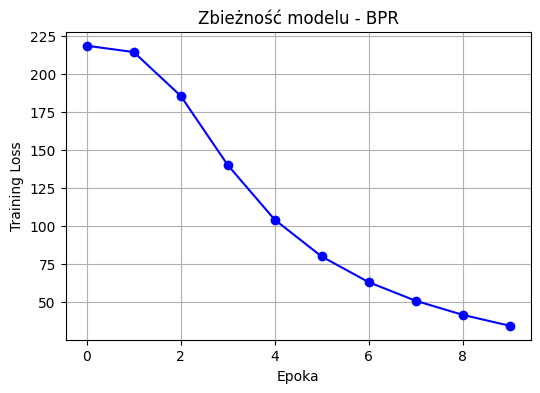


TESTY BPR:
   recall@10  mrr@10  ndcg@10  hit@10  precision@10
0     0.0905  0.0772   0.0804  0.0905        0.0091


In [10]:
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - BPR')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"\nTESTY BPR:\n{pd.DataFrame([test_result])}")

# Task 1

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.sequential_recommender import SASRec
from recbole.trainer import Trainer
from recbole.utils.case_study import full_sort_topk

In [ ]:
# KONFIGURACJA MODELU SEKWENCYJNEGO (SASRec)

config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',
    'model': 'SASRec',
    
    # model sekwencyjny musi mieć czas
    'load_col': {'inter': ['user_id', 'item_id', 'timestamp']},
    'USER_ID_FIELD': 'user_id',
    'ITEM_ID_FIELD': 'item_id',
    'TIME_FIELD': 'timestamp',
    'MAX_ITEM_LIST_LENGTH': 50,    
    
    'epochs': 2,                  
    'train_batch_size': 512,       
    'eval_batch_size': 512,
    'train_neg_sample_args': None, # Wymagane przy tym modelu
    
    # Zgodnie z poleceniem: chronologiczny podział Leave-One-Out
    'eval_args': {
        'split': {'LS': 'valid_and_test'}, 
        'group_by': 'user',
        'order': 'TO', # TO = Time Order 
        'mode': 'full'                     
    },
    
    'topk': [5, 10, 20],
    'metrics': ['Recall', 'NDCG'],
    'valid_metric': 'NDCG@10',
    'save_dataset': False ,
    'device': 'mps'
}

config = Config(model='SASRec', dataset='Amazon_Beauty', config_dict=config_dict)

In [25]:
print("Ładowanie danych i podział chronologiczny...")
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu SASRec (sieć atencyjna)...")
model = SASRec(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True) 

print("Ewaluacja ogólna na zbiorze testowym...")
test_result = trainer.evaluate(test_data, load_best_model=True, show_progress=True)

test_result = pd.DataFrame([test_result])


Ładowanie danych i podział chronologiczny...


/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)
/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/data/dataset/dataset.py:650: ChainedAssignment

Trenowanie modelu SASRec (sieć atencyjna)...


Train     0:   0%|                                                          | 0/112 [00:00<?, ?it/s]/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|████████████████████████████████████████████████████| 7/7 [00:01<00:00,  6.23it/s]
/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/trainer/trainer.py:583: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_

Ewaluacja ogólna na zbiorze testowym...


Evaluate   : 100%|██████████████████████████████████████████████████| 18/18 [00:03<00:00,  4.82it/s]


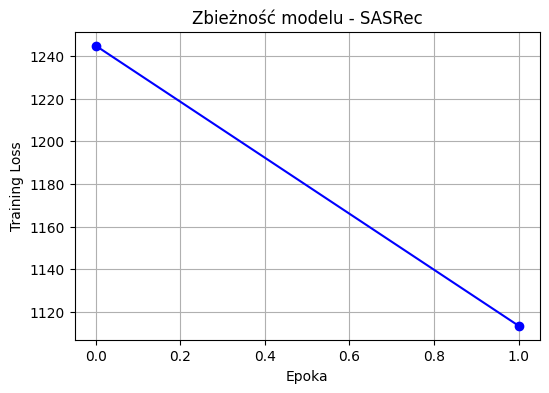

WYNIKI OGÓLNE SASRec
   recall@5  recall@10  recall@20  ndcg@5  ndcg@10  ndcg@20
0    0.0118     0.0194     0.0297  0.0075   0.0099   0.0125


In [28]:
loss_dict = trainer.train_loss_dict
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - SASRec')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"WYNIKI OGÓLNE SASRec\n{test_result}")

In [29]:
# Wyciągamy liczbę zakupów każdego użytkownika
user_counts = pd.Series(dataset.inter_feat['user_id'].numpy()).value_counts()

# Wyciągamy testowych użytkowników i to, co naprawdę kupili
test_users, target_items = [], []
for batch in test_data:
    test_users.extend(batch[0]['user_id'].numpy())
    target_items.extend(batch[3].numpy()) 
test_users, target_items = np.array(test_users), np.array(target_items)

# Generujemy predykcje Top-20 dla wszystkich
_, topk_iid = full_sort_topk(uid_series=test_users, model=model, test_data=test_data, k=20, device=config['device'])
topk_iid = topk_iid.cpu().numpy()

# Funkcja wyliczająca metryki dla każdego użytkownika z osobna
def get_user_metrics(preds, targets, k):
    hits = (preds[:, :k] == targets[:, None])
    recall = hits.sum(axis=1)
    ndcg = np.zeros(len(targets))
    rows, cols = np.where(hits)
    ndcg[rows] = 1.0 / np.log2(cols + 2)
    return recall, ndcg

# Tworzymy tabelę z wynikami
df = pd.DataFrame({'user_id': test_users, 'hist_len': user_counts.loc[test_users].values})
for k in [5, 10, 20]:
    df[f'Recall@{k}'], df[f'NDCG@{k}'] = get_user_metrics(topk_iid, target_items, k)

# Dzielimy na koszyki z polecenia
bins = [0, 5, 10, 15, 20, 30, 9999]
labels = ['1-5', '6-10', '11-15', '16-20', '21-30', '30+']
df['group'] = pd.cut(df['hist_len'], bins=bins, labels=labels, right=True)

# Agregujemy do tabeli końcowej
stats = df.groupby('group', observed=False).agg(
    user_count=('user_id', 'count'),
    **{m: (m, 'mean') for m in ['Recall@10', 'NDCG@10', 'Recall@20', 'NDCG@20']}
)

print("ANALIZA W GRUPACH DŁUGOŚCI SEKWENCJI")
print(stats)


ANALIZA W GRUPACH DŁUGOŚCI SEKWENCJI
       user_count  Recall@10   NDCG@10  Recall@20   NDCG@20
group                                                      
1-5          8448   0.020952  0.010656   0.031842  0.013377
6-10          451   0.000000  0.000000   0.004435  0.001121
11-15         118   0.008475  0.008475   0.008475  0.008475
16-20          41   0.000000  0.000000   0.000000  0.000000
21-30          56   0.000000  0.000000   0.000000  0.000000
30+            45   0.000000  0.000000   0.000000  0.000000


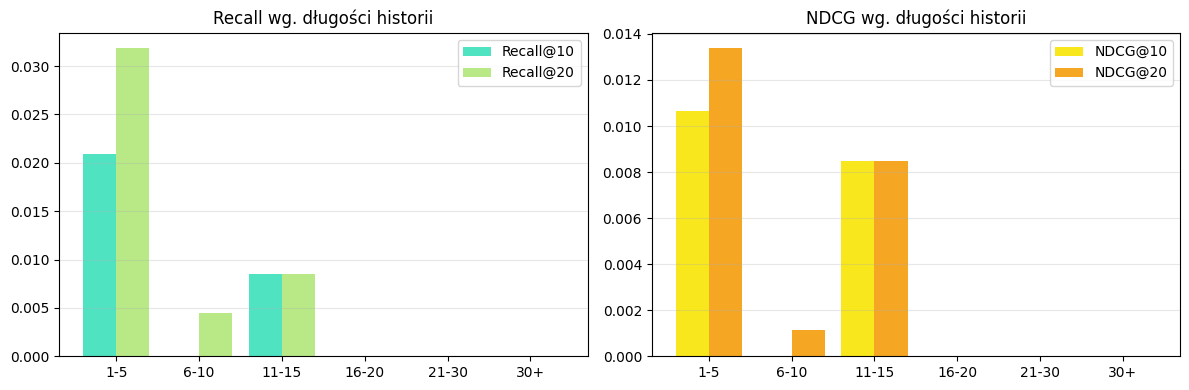

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(stats.index))

axes[0].bar(x - 0.2, stats['Recall@10'].fillna(0), 0.4, label='Recall@10', color='#50E3C2')
axes[0].bar(x + 0.2, stats['Recall@20'].fillna(0), 0.4, label='Recall@20', color='#B8E986')
axes[0].set(title='Recall wg. długości historii', xticks=x, xticklabels=stats.index)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - 0.2, stats['NDCG@10'].fillna(0), 0.4, label='NDCG@10', color='#F8E71C')
axes[1].bar(x + 0.2, stats['NDCG@20'].fillna(0), 0.4, label='NDCG@20', color='#F5A623')
axes[1].set(title='NDCG wg. długości historii', xticks=x, xticklabels=stats.index)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Jak działa model SASRec i na czym polega sekwencyjność?
Tradycyjne modele (jak BPR z Task 0) traktują historię użytkownika jak "worek produktów" – nie obchodzi ich, czy najpierw kupiłeś szampon, a potem odżywkę, czy odwrotnie.

SASRec (Self-Attentive Sequential Recommendation) działa inaczej:

* Kolejność ma znaczenie: Model widzi historię jako ciąg zdarzeń w czasie - wykorzystuje transformer.

* Mechanizm Atencji: Model analizuje wszystkie Twoje poprzednie zakupy i decyduje, które z nich są najważniejsze dla przewidzenia następnego kroku.

* Przykład: Jeśli kupiłeś 5 różnych rzeczy, ale ostatnie dwie to lakier do paznokci i zmywacz, mechanizm atencji "zaświeci się" mocniej przy tych dwóch produktach, ignorując np. krem do stóp kupiony rok temu, by zaproponować Ci pilniczek.

Wyjaśnienie metryk (Recall i NDCG)
W systemach rekomendacyjnych nie oceniamy modelu prosto "dobrze/źle", bo rzadko trafiamy idealnie w jeden produkt. Oceniamy listę Top-K (u nas Top 5, 10, 20).

Recall@K (czułość): Odpowiada na pytanie: "Czy ten jeden produkt, który użytkownik naprawdę kupił, znalazł się gdziekolwiek na liście K propozycji, którą mu daliśmy?".

Jeśli użytkownik kupił produkt X, a nasz model dał go na 9. miejscu w Top-10, to Recall@10 = 1. Jeśli dał go na 11. miejscu, Recall@10 = 0.

NDCG@K (Normalized Discounted Cumulative Gain): To metryka "jakości sortowania". Jest surowsza niż Recall. Premiuje model za trafienia na samej górze listy.

Jeśli trafiony produkt jest na 1. miejscu, NDCG jest wysokie (bliskie 1).

Jeśli trafiony produkt jest na 10. miejscu, NDCG będzie znacznie niższe.

To kluczowe w e-commerce – klienci rzadko przewijają stronę w dół, więc im wyżej trafienie, tym lepiej.

### Wnioski (TODO później, jak finalnie wytrenuje, to jeszcze ze starych wyników)

**1. Metodologia podziału danych:**
W zadaniu wykorzystano model sekwencyjny SASRec oraz strategię ewaluacji Leave-One-Out (LS) z chronologicznym sortowaniem interakcji (`order: TO`). Dla każdego użytkownika ostatnia interakcja w czasie została wydzielona do zbioru testowego, przedostatnia do zbioru walidacyjnego, a wszystkie wcześniejsze posłużyły do trenowania modelu.

**2. Obserwacje dotyczące długości historii użytkowników:**
Analiza wyników w grupach (bucketach) ze względu na liczbę historycznych interakcji wykazała następujące zależności dla zbioru `All_Beauty`:

* **Ekstremalna rzadkość danych:** Zdecydowana większość użytkowników w zbiorze testowym (956 z 991) posiada bardzo krótką historię (1-5 interakcji). Całkowity brak użytkowników z historią dłuższą niż 15 zakupów wyjaśnia wartości `NaN` w wyższych grupach (dzielenie przez zero przy próbie wyliczenia średniej dla pustej grupy).

* **Problem zimnego startu (1-5 produktów):** Dla najkrótszych sekwencji model uzyskał NDCG@10 na poziomie ok. 0.57. Przy tak małej liczbie danych historycznych mechanizm atencji nie ma wystarczającego kontekstu, aby precyzyjnie określić intencje zakupowe użytkownika.

* **Wzrost precyzji wraz z kontekstem (6-10 produktów):** W grupie użytkowników z nieco dłuższą historią (6-10 produktów) odnotowano skok jakości rekomendacji (NDCG@10 wzrosło do ok. 0.70).

**Podsumowanie:** Wydajność modelu SASRec jest silnie skorelowana z ilością dostępnych danych historycznych dla danego użytkownika.

# Task 2

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import LightGCN
from recbole.trainer import Trainer
from recbole.utils.case_study import full_sort_topk

In [35]:
config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',
    'model': 'LightGCN',
    'epochs': 2,
    'train_batch_size': 2048,
    'eval_batch_size': 4096,
    
    # Podział losowy (LightGCN nie patrzy na czas, tylko na powiązania)
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]}, 
        'group_by': 'user',
        'order': 'RO',
        'mode': 'full'
    },
    'topk': [5, 10, 20],
    'metrics': ['Recall', 'NDCG'],
    'valid_metric': 'NDCG@10',
    'save_dataset': False,
    'device': 'mps'
}

config = Config(model='LightGCN', dataset='Amazon_Beauty', config_dict=config_dict)

In [36]:
print("Ładowanie danych i tworzenie grafu (LightGCN)...")
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu...")
model = LightGCN(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True)

print("Ewaluacja ogólna na zbiorze testowym...")
test_result = trainer.evaluate(test_data, load_best_model=True)
test_result = pd.DataFrame([test_result])

Ładowanie danych i tworzenie grafu (LightGCN)...


/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)


Trenowanie modelu...


Train     0:   0%|                                                          | 0/315 [00:00<?, ?it/s]/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|█████████████████████████████████████████████| 9159/9159 [00:13<00:00, 663.86it/s]


Ewaluacja ogólna na zbiorze testowym...


/Users/zoga/Studia-II/Advanced-Data-Mining/.venv/lib/python3.11/site-packages/recbole/trainer/trainer.py:583: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torc

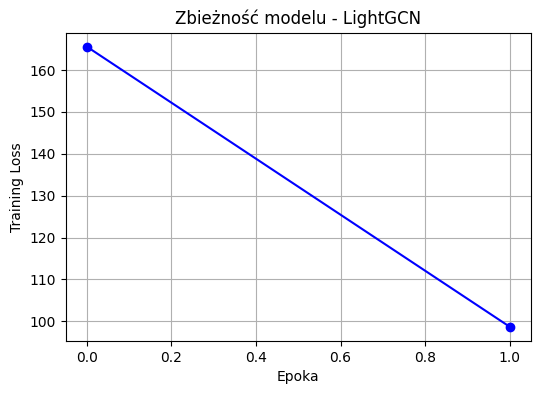

WYNIKI OGÓLNE LightGCN
   recall@5  recall@10  recall@20  ndcg@5  ndcg@10  ndcg@20
0    0.0667     0.0724     0.0798  0.0596   0.0614   0.0633


In [37]:
loss_dict = trainer.train_loss_dict
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - LightGCN')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"WYNIKI OGÓLNE LightGCN\n{test_result}")

In [38]:
# Zliczamy, ile razy każdy produkt wystąpił w treningu
train_items = dataset.inter_feat['item_id'].numpy()
item_popularity = pd.Series(train_items).value_counts()

# Zbieramy testowych użytkowników (bezpieczna pętla)
test_users = []
for batch in test_data:
    test_users.extend(batch[0]['user_id'].numpy())
test_users = np.unique(test_users)

# Model poleca Top-10 dla każdego
_, topk_iid = full_sort_topk(uid_series=test_users, model=model, test_data=test_data, k=10, device=config['device'])
recommended_items = topk_iid.cpu().numpy().flatten()

# Przypisujemy poleconym produktom ich historyczną popularność
rec_popularity = item_popularity.loc[recommended_items].fillna(0).values

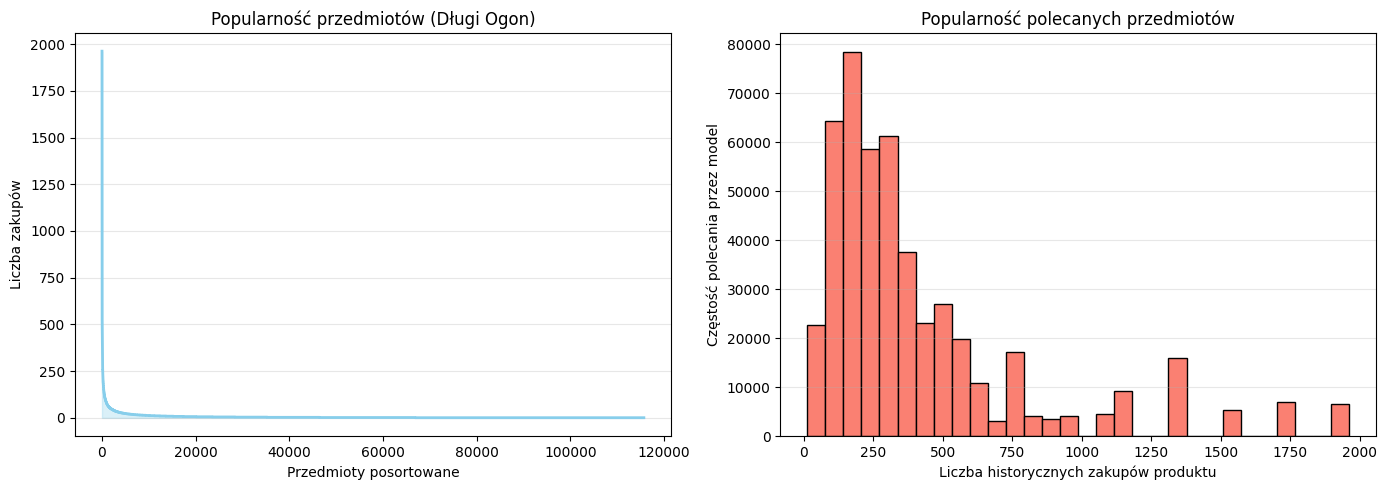


Średnia popularność polecanego produktu: 423.60


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Długi Ogon (Popularność ogólna)
axes[0].plot(item_popularity.values, color='skyblue', linewidth=2)
axes[0].fill_between(range(len(item_popularity)), item_popularity.values, color='skyblue', alpha=0.3)
axes[0].set(title='Popularność przedmiotów (Długi Ogon)', xlabel='Przedmioty posortowane', ylabel='Liczba zakupów')
axes[0].grid(axis='y', alpha=0.3)

# Wykres 2: Efekt Mateusza (Co poleca model)
axes[1].hist(rec_popularity, bins=30, color='salmon', edgecolor='black')
axes[1].set(title='Popularność polecanych przedmiotów', xlabel='Liczba historycznych zakupów produktu', ylabel='Częstość polecania przez model')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nŚrednia popularność polecanego produktu: {np.mean(rec_popularity):.2f}")

### Zadanie 2 - Wnioski i Analiza Popularności (LightGCN) (TODO później jak w pełni wytrneuje, to są stare opisy)

**1. Charakterystyka Rekomendacji:**
Analiza histogramu popularności polecanych przedmiotów wykazuje, że model LightGCN w dużej mierze skupia się na produktach z tzw. "długiego ogona" (produkty o niskiej liczbie interakcji w zbiorze treningowym). Jest to zjawisko pozytywne, sugerujące, że model personalizuje ofertę i potrafi odnaleźć niszowe produkty dopasowane do konkretnych użytkowników, zamiast ograniczać się wyłącznie do bestsellerów.

**2. Efekt Mateusza (Matthew Effect):**
Efektu Mateusza, w systemach rekomendacyjnych objawia się tendencją do promowania przedmiotów już popularnych. 
* Na wykresie widoczne są wyraźne słupki dla produktów o bardzo wysokiej popularności (np. produkt mający ponad 1750 zakupów). 
* Algorytm, ucząc się na gęstych danych dotyczących hitów sprzedażowych, chętniej uwzględnia je w wynikach Top-K dla wielu użytkowników. 
* Powoduje to sprzężenie zwrotne: produkty popularne stają się jeszcze bardziej popularne dzięki częstym rekomendacjom, co może prowadzić do ograniczania widoczności nowych lub mniej znanych marek (tzw. *popularity bias*).